# Кластеризация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score)
from tqdm import tqdm
import os
import sys

sys.path.append('..')
from utils import (dunn_index, compute_gap_statistic, get_cluster_report, get_centroid_examples)

RANDOM_STATE = 42

Загрузка данных

In [2]:
df = pd.read_csv(
    "../data/split/02_text_for_vectorization.csv"
)

X_bge = np.load(
    "../data/embeddings/bge.npy"
)

Нормализация

In [3]:
X_bge_norm = normalize(X_bge)

Grid Search KMeans

In [11]:
pca_dims = [50, 100, 200, None]

k_range = range(5, 21)

results_bge = []

for n_comp in pca_dims:

    print("=" * 80)
    print(f"PCA = {n_comp}")
    print("=" * 80)

    if n_comp is not None:

        pca = PCA(
            n_components=n_comp,
            random_state=RANDOM_STATE
        )

        X_current = pca.fit_transform(
            X_bge_norm
        )

        print(f"After PCA: "f"{X_current.shape}")

    else:

        X_current = X_bge_norm
        print("Without PCA")

    for k in tqdm(
        k_range,
        desc=f"KMeans PCA={n_comp}"
    ):

        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init='auto'
        )

        labels = km.fit_predict(
            X_current
        )

        sil = silhouette_score(
            X_current,
            labels
        )

        ch = calinski_harabasz_score(
            X_current,
            labels
        )

        db = davies_bouldin_score(
            X_current,
            labels
        )

        dunn = dunn_index(
            X_current,
            labels
        )

        gap = compute_gap_statistic(
            X_current,
            k
        )

        results_bge.append({
            'pca_dim': n_comp,
            'k': k,
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db,
            'dunn': dunn,
            'gap': gap,
            'wss': km.inertia_
        })

df_bge_metrics = pd.DataFrame(
    results_bge
)

os.makedirs(
    "../data/results/metrics/bge",
    exist_ok=True
)

df_bge_metrics.to_csv(
    "../data/results/metrics/bge/"
    "bge_kmeans_metrics.csv",
    index=False
)

df_bge_metrics.head()

PCA = 50
After PCA: (10467, 50)


KMeans PCA=50: 100%|██████████| 16/16 [01:06<00:00,  4.15s/it]


PCA = 100
After PCA: (10467, 100)


KMeans PCA=100: 100%|██████████| 16/16 [01:31<00:00,  5.69s/it]


PCA = 200
After PCA: (10467, 200)


KMeans PCA=200: 100%|██████████| 16/16 [02:28<00:00,  9.28s/it]


PCA = None
Without PCA


KMeans PCA=None: 100%|██████████| 16/16 [09:32<00:00, 35.78s/it]


,pca_dim,k,silhouette,calinski_harabasz,davies_bouldin,dunn,gap,wss
0,50.0,5,0.061484,530.800046,3.374286,0.161904,2.829742,2473.341797
1,50.0,6,0.062355,487.069045,3.180842,0.117753,2.848992,2413.438232
2,50.0,7,0.064483,445.988089,3.095059,0.156455,2.861350,2369.194092
3,50.0,8,0.069174,427.467729,3.129202,0.190032,2.880235,2313.431641
4,50.0,9,0.072098,407.251554,3.052872,0.158606,2.895293,2268.561279


Посмотрим на метрики на графиках

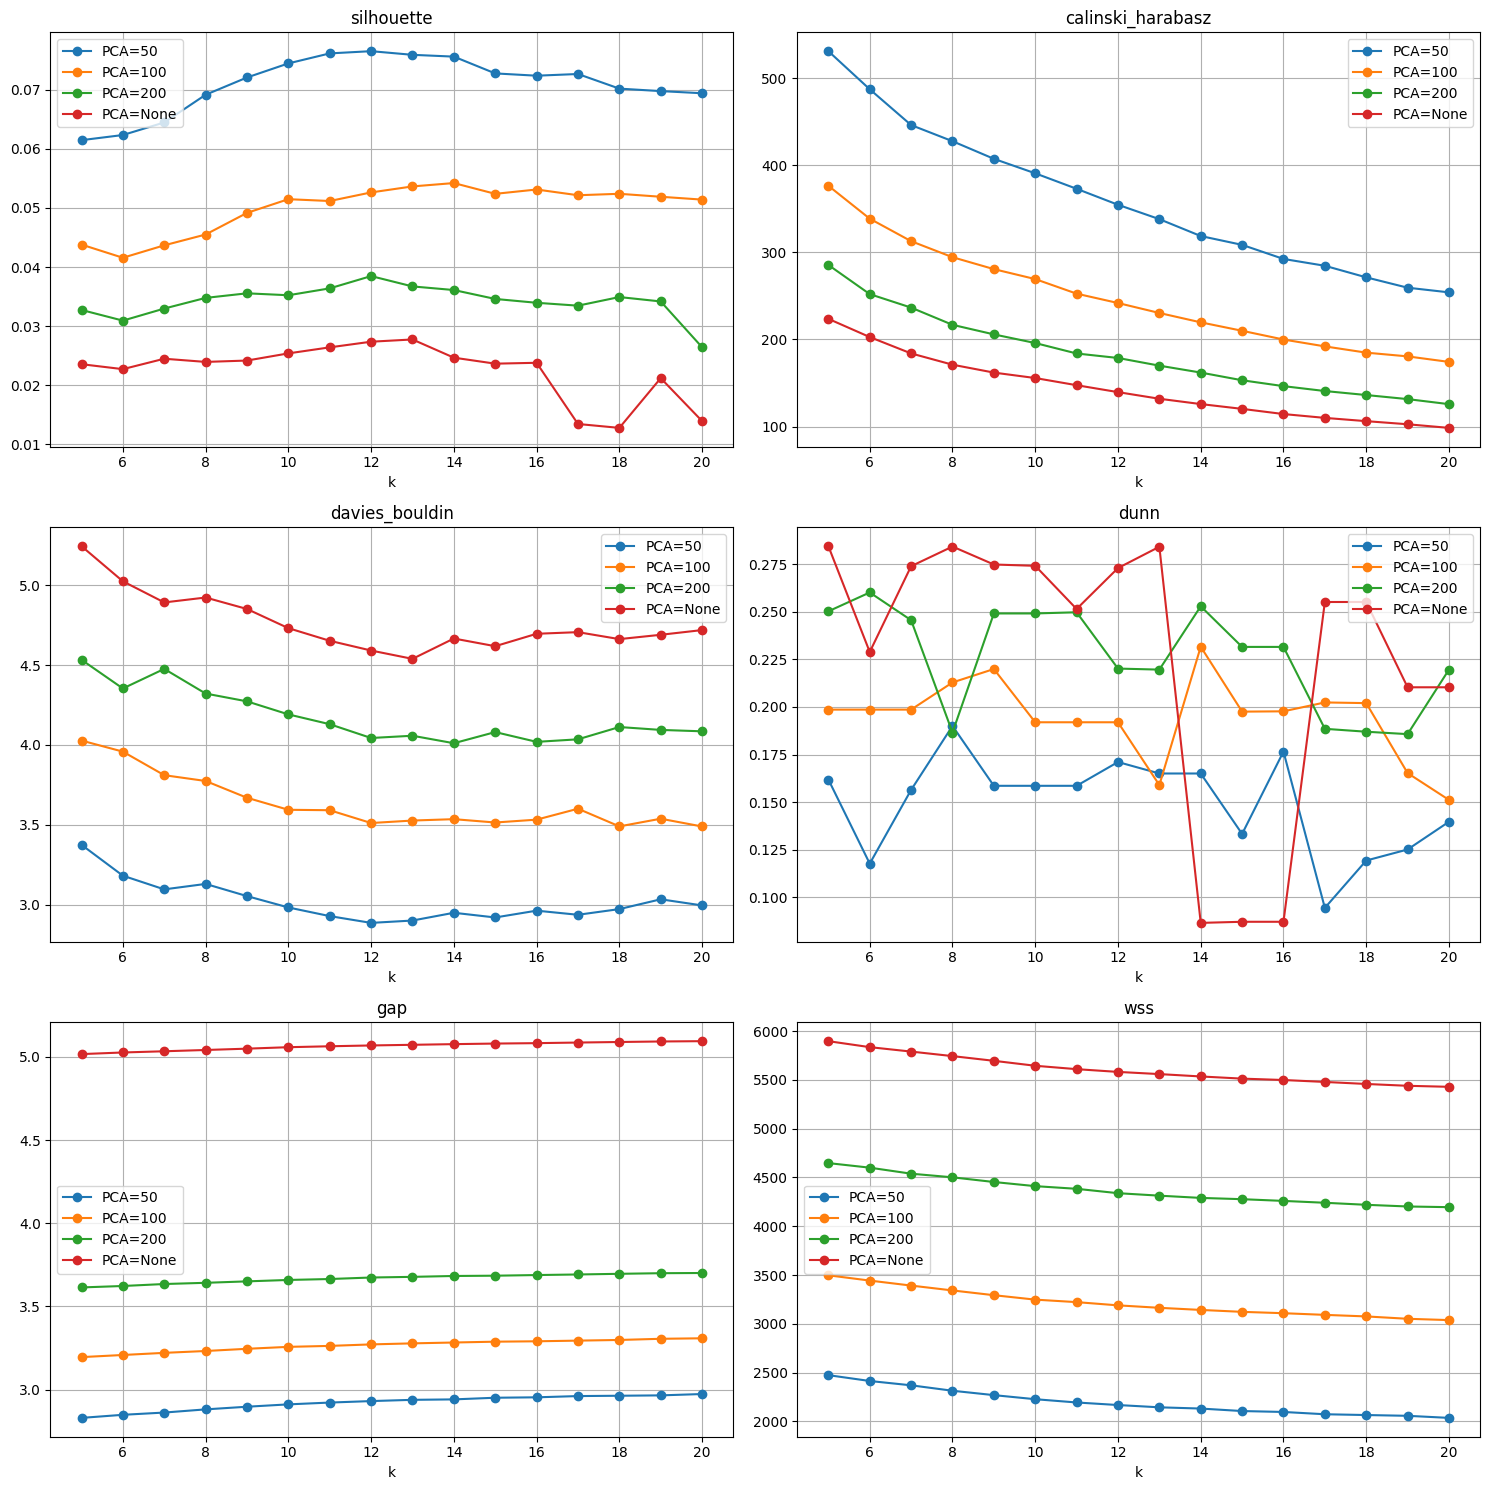

In [ ]:
metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dunn",
    "gap",
    "wss"
]

pca_candidates = [
    50,
    100,
    200,
    np.nan
]

n_cols = 2
n_rows = 3

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(15, 5 * n_rows) 
)

axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    
    for pca_dim in pca_candidates:
        if pd.isna(pca_dim):
            subset = df_bge_metrics[
                df_bge_metrics["pca_dim"].isna()
            ]
            label = "PCA=None"
        else:
            subset = df_bge_metrics[
                df_bge_metrics["pca_dim"] == pca_dim
            ]
            label = f"PCA={pca_dim}"
        
        ax.plot(
            subset["k"],
            subset[metric],
            marker="o",
            label=label
        )
    
    ax.set_title(metric)
    ax.set_xlabel("k")
    ax.grid(True)
    ax.legend()

plt.tight_layout()

os.makedirs(
    "../data/plots/bge/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/bge/kmeans/bge_kmeans_metrics.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Лучше всего показала себя размерность PCA = 50. Она обеспечивает лучший баланс между сжатием пространства и сохранением семантической структуры.

Посмотрим размеры кластеров для следующих k: 12, 13, 14, 15, 16, 18

In [4]:
FINAL_PCA_BGE = 50

pca_final = PCA(
    n_components=FINAL_PCA_BGE,
    random_state=RANDOM_STATE
)

X_bge_final = pca_final.fit_transform(
    X_bge_norm
)

In [ ]:
k_candidates = [12, 13, 14, 15, 16, 18]

In [ ]:
cluster_sizes_report = {}

for k in k_candidates:

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_bge_final
    )

    df_temp = df.copy()

    df_temp['cluster'] = labels

    report = get_cluster_report(
        df_temp,
        'cluster'
    )

    cluster_sizes_report[k] = report

summary_data = []

for k in k_candidates:

    report = cluster_sizes_report[k]

    summary_data.append({

        'k': k,
        'min_cluster': report['min_size'],
        'max_cluster': report['max_size'],
        'max_cluster_pct':
            f"{report['max_size_pct']:.1%}"
    })

df_summary_bge = pd.DataFrame(summary_data)

df_summary_bge

,k,min_cluster,max_cluster,max_cluster_pct
0,12,544,1151,11.0%
1,13,543,1074,10.3%
2,14,469,1070,10.2%
3,15,305,1033,9.9%
4,16,301,925,8.8%
5,18,294,910,8.7%


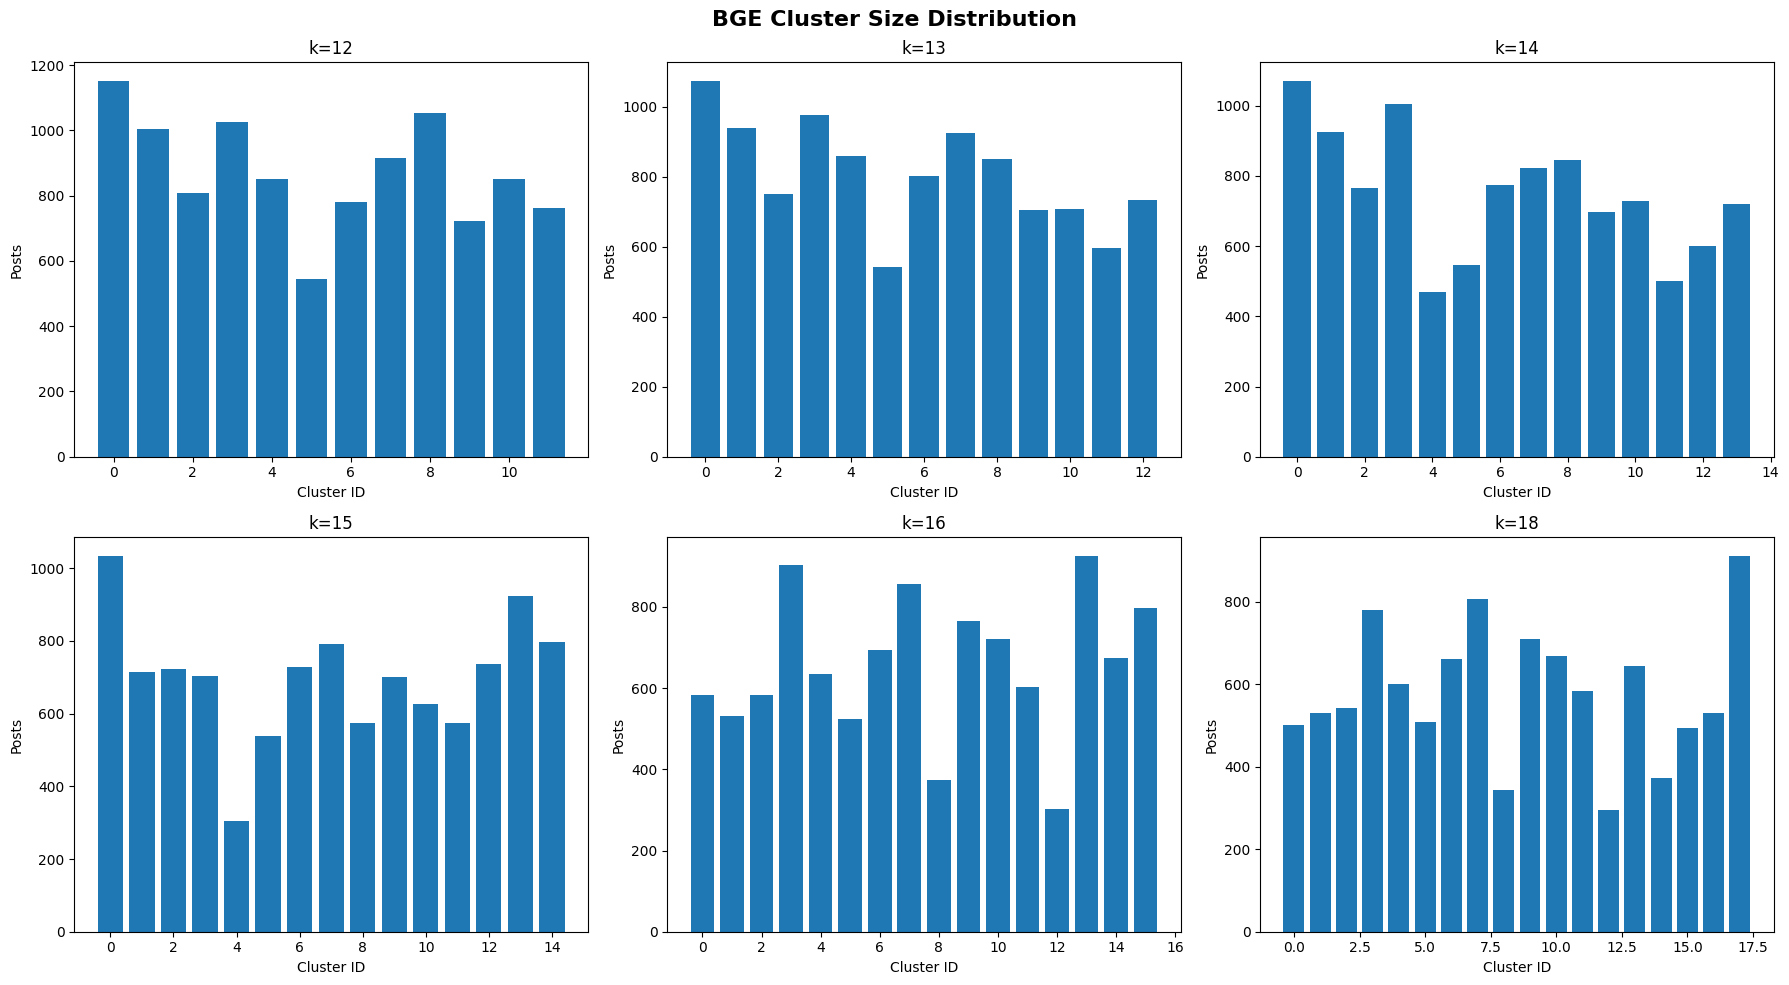

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, k in enumerate(k_candidates):

    sizes = cluster_sizes_report[k]['sizes']

    axes[idx].bar(
        range(len(sizes)),
        list(sizes.values())
    )
    axes[idx].set_title(f'k={k}')
    axes[idx].set_xlabel('Cluster ID')
    axes[idx].set_ylabel('Posts')

plt.suptitle(
    'BGE Cluster Size Distribution',
    fontsize=16,
    fontweight='bold'
)

# axes[-1].axis('off')

plt.tight_layout()

os.makedirs(
    "../data/plots/bge/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/bge/kmeans/"
    "bge_cluster_sizes.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Посмотрим теперь на примеры кластеров для этих k

In [119]:
final_candidates_bge = [12, 13, 14, 15, 16, 18]

Создание кластеров для каждого k

In [ ]:
base_examples_path = (
    "../data/results/candidate_examples/bge"
)

base_clusters_path = (
    "../data/results/final_clusters/bge"
)

os.makedirs(
    base_examples_path,
    exist_ok=True
)

os.makedirs(
    base_clusters_path,
    exist_ok=True
)

for k in final_candidates_bge:

    print("\n" + "=" * 80)
    print(f"k = {k}")
    print("=" * 80)

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )

    labels = km.fit_predict(
        X_bge_final
    )

    df_cluster = df.copy()

    df_cluster['cluster'] = labels

    cluster_sizes = (
        df_cluster['cluster']
        .value_counts()
        .sort_index()
    )

    df_cluster['cluster_size'] = (
        df_cluster['cluster']
        .map(cluster_sizes)
    )

    centroid_examples = get_centroid_examples(
        X_bge_final,
        labels,
        df,
        n_examples=50
    )

    
    output_txt = (
        f"{base_examples_path}/"
        f"bge_k{k}_candidate_examples.txt"
    )

    with open(output_txt, "w", encoding="utf-8") as f:

        f.write("=" * 80 + "\n")
        f.write("BGE + KMeans\n")
        f.write(f"k = {k}\n")
        f.write(
            "TOP-50 nearest centroid examples\n"
        )
        f.write("=" * 80 + "\n\n")

        f.write("CLUSTER SIZES:\n\n")

        for cluster_id, size in cluster_sizes.items():

            f.write(
                f"Cluster {cluster_id}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        for cluster_id in sorted(cluster_sizes.index):

            f.write(f"\n{'=' * 80}\n")

            f.write(
                f"CLUSTER {cluster_id} "
                f"({cluster_sizes[cluster_id]} posts)\n"
            )

            f.write(f"{'=' * 80}\n\n")

            examples = centroid_examples.get(
                cluster_id,
                {}
            )

            texts = examples.get('texts', [])

            distances = examples.get(
                'distances',
                []
            )

            for idx, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(
                    str(text)
                    .replace('\n', ' ')
                    .split()
                )

                f.write(
                    f"[{idx+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(f"{clean_text}\n\n")

    print(f"Сохранен TXT: {output_txt}")

    output_csv = (
        f"{base_clusters_path}/"
        f"bge_k{k}_clusters.csv"
    )

    df_cluster[
        [
            'post_id',
            'channel_username',
            'text',
            'cluster',
            'cluster_size'
        ]
    ].to_csv(
        output_csv,
        index=False
    )

    print(f"Сохранен CSV: {output_csv}")



k = 12
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k12_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k12_clusters.csv

k = 13
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k13_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k13_clusters.csv

k = 14
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k14_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k14_clusters.csv

k = 15
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k15_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k15_clusters.csv

k = 16
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k16_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k16_clusters.csv

k = 18
Сохранен TXT: ../data/results/candidate_examples/bge/bge_k18_candidate_examples.txt
Сохранен CSV: ../data/results/final_clusters/bge/bge_k18_clusters.csv


k=12: Кластеры получились слишком обобщенными: IT-новости и Telegram слиты в один кластер (Cluster 4), а Cluster 7 представляет собой неинтерпретируемый «мусорный» кластер из разнородных тем.

k=13: Ситуация улучшилась, из смешанного кластера выделились Telegram-новости в отдельный кластер (Cluster 5), но сохраняются размытые, слабо интерпретируемые кластеры.

k=14: Аналогично k=13: есть позитивное дробление, но проблема мусорных кластеров не решена, некоторые темы остаются размытыми.

k=15: Оптимальная конфигурация. Кластеры тематически однородны, нет явного пересечения тем, отсутствуют «мусорные» кластеры, размеры сбалансированы.

k=16: Появляется избыточная фрагментация, тема «Сколтех» дробится на три кластера, возникают очень маленькие (373 поста) и слабо интерпретируемые кластеры.

k=18: Сильный дисбаланс размеров, избыточное дробление одной темы на несколько похожих кластеров, появление микрокластеров.


Итоговый выбор: **k=15**

In [5]:
FINAL_K_BGE = 15

Фиксируем финальную версию

In [6]:
pca_final = PCA(
    n_components=FINAL_PCA_BGE,
    random_state=RANDOM_STATE
)

X_bge_final = pca_final.fit_transform(
    X_bge_norm
)


km_final = KMeans(
    n_clusters=FINAL_K_BGE,
    random_state=RANDOM_STATE,
    n_init='auto'
)

labels_final = km_final.fit_predict(
    X_bge_final
)


df_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_cluster_final['cluster_bge'] = labels_final

cluster_sizes = (
    df_cluster_final['cluster_bge']
    .value_counts()
    .sort_index()
)

df_cluster_final['cluster_bge_size'] = (
    df_cluster_final['cluster_bge']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [13]:
cluster_names_bge = {
    0: "Регулирование: блокировки Рунета",
    1: "Игры: анонсы видеоигр и кино",
    2: "Университет: мероприятия и студенты СПбГУ",
    3: "Наука и ИИ: исследования и конференции Сколтеха",
    4: "Новости: быстрые новости (Apple, Игры, Крипта)",
    5: "Telegram: подарки, Premium, TON",
    6: "IT-образование: школы и стажировки по IT/ML",
    7: "Психология: наука о мозге и обучение",
    8: "ИИ-инструменты: ТРИЗ, RAG, лайфхаки",
    9: "Apple: слухи и новости об iPhone/Android",
    10: "Новости: утренние дайджесты об ИИ",
    11: "Тренды ИИ: глубокий разбор LLM и бенчмарков",
    12: "Новости: DDoS-атаки, сбои, запреты",
    13: "ИИ-инструменты: сервисы для работы",
    14: "Юмор: визуальный юмор и атмосферные посты",
}

In [14]:
df_cluster_final['cluster_bge_name'] = (
    df_cluster_final['cluster_bge']
    .map(cluster_names_bge)
)

Посмотрим на распределение кластеров

In [15]:
distribution = (
    df_cluster_final[
        [
            'cluster_bge',
            'cluster_bge_name',
            'cluster_bge_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_bge')
)

distribution

,cluster_bge,cluster_bge_name,cluster_bge_size
568,0,Регулирование: блокировки Рунета,1033
771,1,Игры: анонсы видеоигр и кино,715
351,2,Университет: мероприятия и студенты СПбГУ,722
5,3,Наука и ИИ: исследования и конференции Сколтеха,703
716,4,"Новости: быстрые новости (Apple, Игры, Крипта)",305
125,5,"Telegram: подарки, Premium, TON",538
47,6,IT-образование: школы и стажировки по IT/ML,729
10,7,Психология: наука о мозге и обучение,792
0,8,"ИИ-инструменты: ТРИЗ, RAG, лайфхаки",574
762,9,Apple: слухи и новости об iPhone/Android,700


Сохраняем

In [16]:
os.makedirs(
    "../data/results/final_examples/bge",
    exist_ok=True
)

centroid_examples = get_centroid_examples(
    X_bge_final,
    labels_final,
    df,
    n_examples=50
)

output_path = (
    "../data/results/final_examples/"
    "bge/bge_final_examples.txt"
)

with open(output_path, "w", encoding="utf-8") as f:

    f.write("=" * 80 + "\n")
    f.write("BGE + KMeans FINAL CLUSTERIZATION\n")
    f.write(f"PCA = {FINAL_PCA_BGE}\n")
    f.write(f"k = {FINAL_K_BGE}\n")
    f.write("=" * 80 + "\n\n")

    f.write("CLUSTER SIZES:\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        size = cluster_sizes[cluster_id]

        name = cluster_names_bge.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(
            f"Cluster {cluster_id} "
            f"({name}): {size} posts\n"
        )

    f.write("\n" + "=" * 80 + "\n\n")

  
    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_bge.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(
            f"Posts: {cluster_sizes[cluster_id]}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        texts = centroid_examples[
            cluster_id
        ]['texts']

        distances = centroid_examples[
            cluster_id
        ]['distances']

        for idx, (text, dist) in enumerate(
            zip(texts, distances)
        ):

            clean_text = ' '.join(
                str(text)
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[{idx+1}] "
                f"(distance: {dist:.4f})\n"
            )

            f.write(f"{clean_text}\n\n")


   
    f.write("\n" + "=" * 80 + "\n")
    f.write("RANDOM EXAMPLES\n")
    f.write("=" * 80 + "\n\n")

    for cluster_id in sorted(cluster_sizes.index):

        name = cluster_names_bge.get(
            cluster_id,
            "UNDEFINED"
        )

        f.write(f"\n{'=' * 80}\n")

        f.write(
            f"CLUSTER {cluster_id}: "
            f"{name}\n"
        )

        f.write(f"{'=' * 80}\n\n")

        cluster_texts = df_cluster_final[
            df_cluster_final['cluster_bge']
            == cluster_id
        ]['text'].tolist()

        random_indices = np.random.choice(
            len(cluster_texts),
            size=min(20, len(cluster_texts)),
            replace=False
        )

        for idx, text_idx in enumerate(
            random_indices
        ):

            clean_text = ' '.join(
                str(cluster_texts[text_idx])
                .replace('\n', ' ')
                .split()
            )

            f.write(
                f"[RANDOM {idx+1}]\n"
            )

            f.write(f"{clean_text}\n\n")

In [17]:
os.makedirs(
    "../data/results/final_clusters/bge",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "bge/bge_final_clusters.csv"
)

df_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


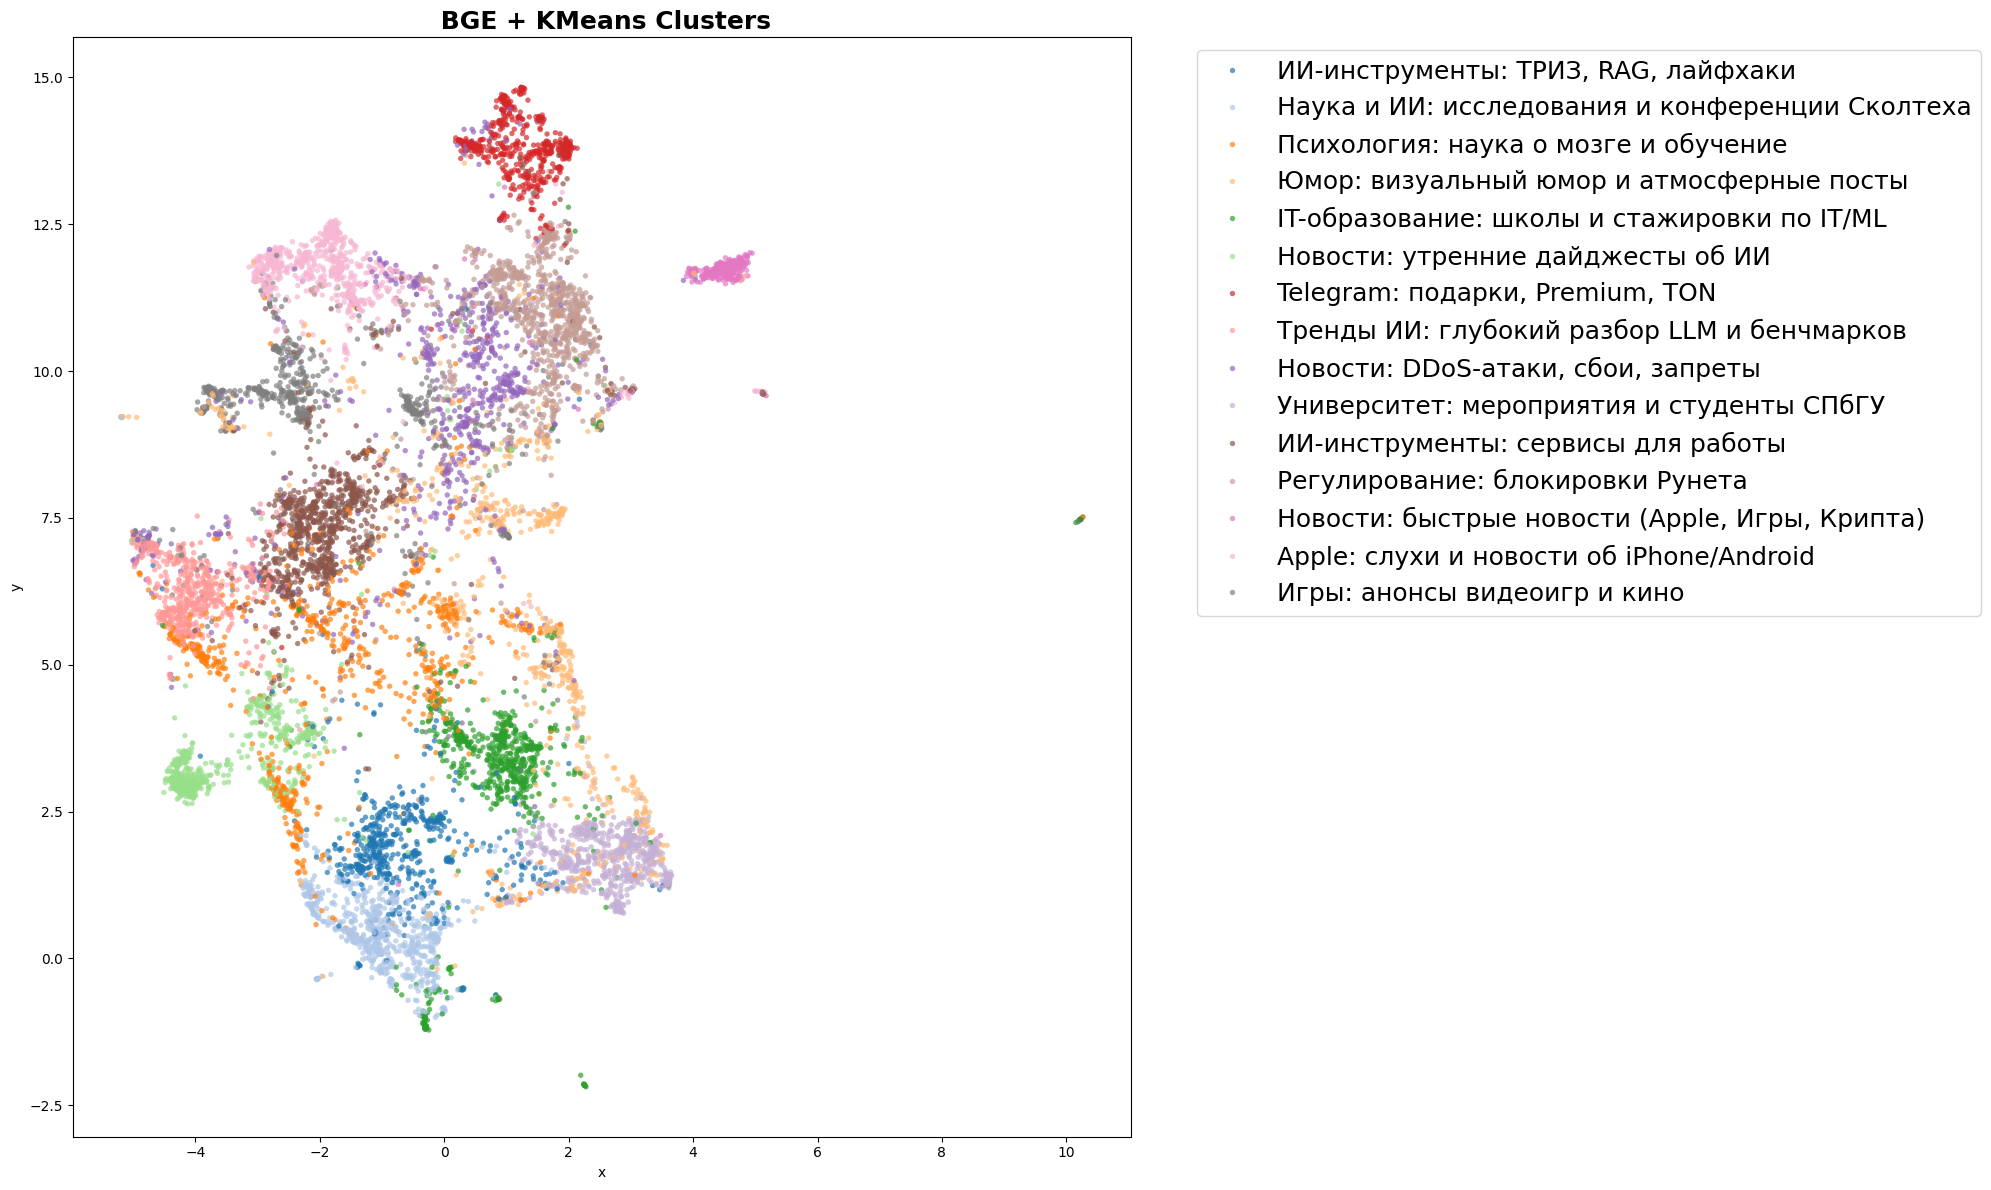

In [20]:
import umap.umap_ as umap

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_bge_final
)

plot_df = pd.DataFrame({
    'x': X_umap[:, 0],
    'y': X_umap[:, 1],
    'cluster_name':
        df_cluster_final[
            'cluster_bge_name'
        ]
})

plt.figure(figsize=(20, 12))

sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='cluster_name',
    palette='tab20',
    s=15,
    alpha=0.7,
    linewidth=0
)

plt.title(
    ' BGE + KMeans Clusters',
    fontsize=18,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=18
)

plt.tight_layout()

os.makedirs(
    "../data/plots/bge/kmeans",
    exist_ok=True
)

plt.savefig(
    "../data/plots/bge/kmeans/"
    "bge_kmeans_final_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# HDBSCAN для BGE

In [ ]:
min_cluster_sizes = [100, 150, 200]
min_samples_list = [1, 3, 5]
umap_n_neighbors = [50, 100, 150]
umap_n_components = [10, 15, 20]

In [ ]:
from hdbscan.validity import validity_index
import warnings
import hdbscan
from umap import UMAP

warnings.filterwarnings("ignore")

results_hdbscan = []

for nn in umap_n_neighbors:

    for nc in umap_n_components:

        print("=" * 80)
        print(f"UMAP neighbors={nn}, components={nc}")

        umap_model = UMAP(
            n_neighbors=nn,
            n_components=nc,
            min_dist=0.1,
            metric='cosine',
            random_state=42
        )

        X_umap = umap_model.fit_transform(X_bge_norm)
        X_umap = X_umap.astype(np.float64)

        for mcs in min_cluster_sizes:

            for ms in min_samples_list:

                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=mcs,
                    min_samples=ms,
                    metric='euclidean',
                    cluster_selection_method='eom',
                    prediction_data=True,
                    core_dist_n_jobs=-1
                )

                labels = clusterer.fit_predict(
                    X_umap
                )

                n_clusters = len(
                    set(labels)
                ) - (1 if -1 in labels else 0)

                noise_ratio = np.mean(
                    labels == -1
                )

                sil = np.nan
                dbcv = np.nan

                valid_mask = labels != -1

                unique_valid = np.unique(
                    labels[valid_mask]
                )

                if len(unique_valid) >= 2:
                    try:
                        sil = silhouette_score(
                            X_umap[valid_mask],
                            labels[valid_mask],
                            metric='euclidean'
                        )

                    except:
                        pass

                try:
                    dbcv = validity_index(
                        X_umap,
                        labels
                    )

                except:
                    pass

                results_hdbscan.append({
                    'umap_neighbors': nn,
                    'umap_components': nc,
                    'min_cluster_size': mcs,
                    'min_samples': ms,
                    'n_clusters': n_clusters,
                    'noise_ratio': noise_ratio,
                    'silhouette': sil,
                    'dbcv': dbcv
                })

UMAP neighbors=50, components=10
UMAP neighbors=50, components=15
UMAP neighbors=50, components=20
UMAP neighbors=100, components=10
UMAP neighbors=100, components=15
UMAP neighbors=100, components=20
UMAP neighbors=150, components=10
UMAP neighbors=150, components=15
UMAP neighbors=150, components=20


In [ ]:
df_hdbscan = pd.DataFrame(
    results_hdbscan
)

os.makedirs(
    "../data/results/metrics/bge",
    exist_ok=True
)

df_hdbscan.to_csv(
    "../data/results/metrics/bge/"
    "bge_hdbscan_metrics.csv",

    index=False
)

df_hdbscan.head()

,umap_neighbors,umap_components,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,dbcv
0,50,10,100,1,16,0.201204,0.404983,-0.087105
1,50,10,100,3,12,0.215917,0.434080,0.016137
2,50,10,100,5,16,0.319862,0.512380,0.105763
3,50,10,150,1,13,0.268558,0.380379,-0.114995
4,50,10,150,3,9,0.248877,0.492604,-0.001460


In [12]:
df_hdbscan_filtered = df_hdbscan[
    (df_hdbscan['n_clusters'] >= 5) &
    (df_hdbscan['n_clusters'] <= 20) &
    (df_hdbscan['noise_ratio'] <= 0.50) & 
    (df_hdbscan['dbcv'] >= 0) &
    (df_hdbscan['silhouette'] >= 0.30)

].sort_values(
    ['dbcv', 'silhouette'],
    ascending=False

)

df_hdbscan_filtered.reset_index(drop=True)

NameError: name 'df_hdbscan' is not defined

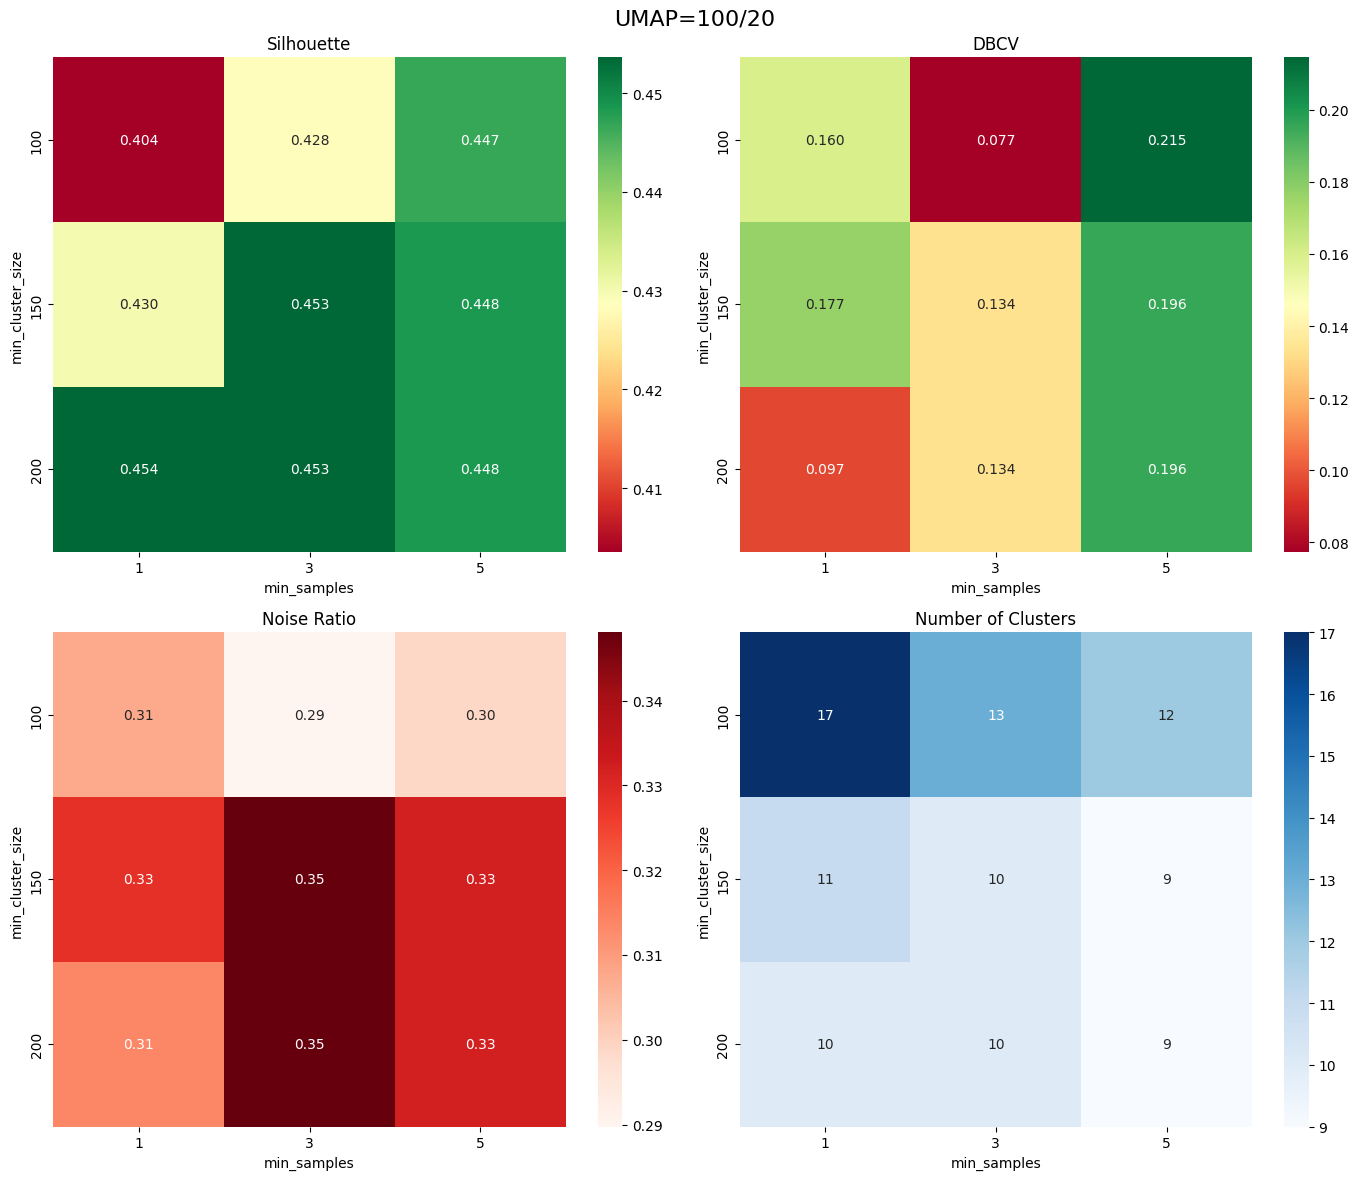

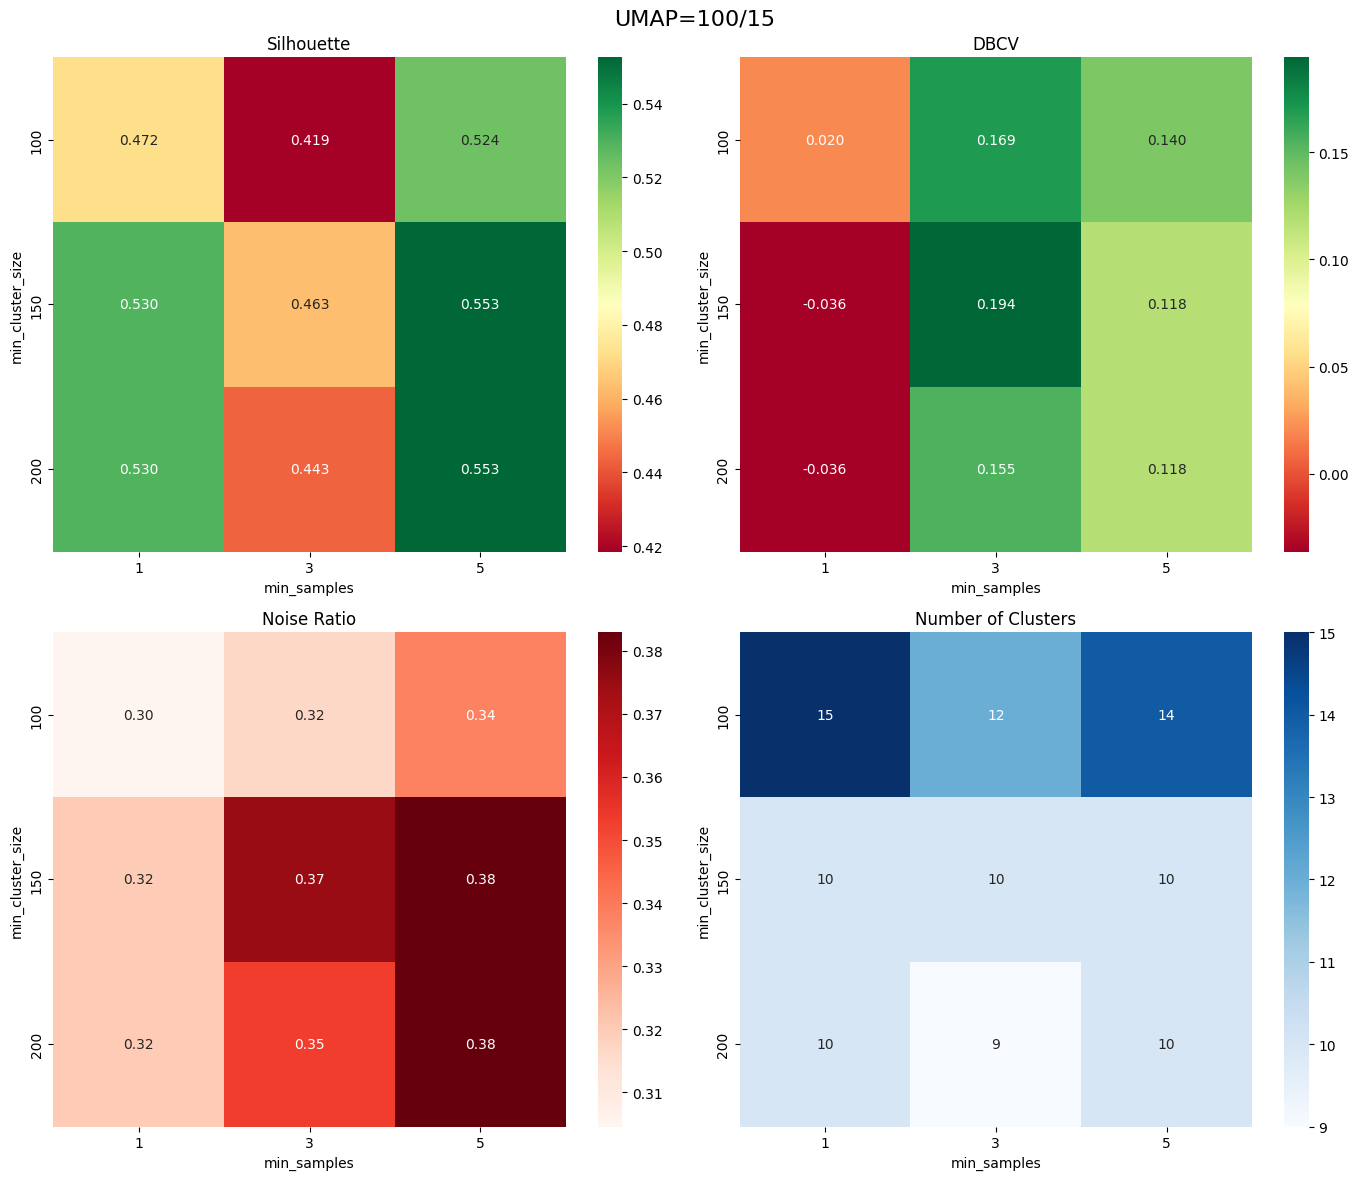

In [ ]:
top_configs = df_hdbscan_filtered[
    [
        'umap_neighbors',
        'umap_components'
    ]
].drop_duplicates()

for _, row in top_configs.iterrows():
    nn = row['umap_neighbors']
    nc = row['umap_components']

    subset = df_hdbscan[
        (df_hdbscan['umap_neighbors'] == nn) &
        (df_hdbscan['umap_components'] == nc)

    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 12)
    )


    # SILHOUETTE
    pivot_sil = subset.pivot_table(
        values='silhouette',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_sil,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        'Silhouette'
    )

    # DBCV
    pivot_dbcv = subset.pivot_table(
        values='dbcv',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_dbcv,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        'DBCV'
    )

    # NOISE
    pivot_noise = subset.pivot_table(
        values='noise_ratio',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_noise,
        annot=True,
        fmt='.2f',
        cmap='Reds',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        'Noise Ratio'
    )

    # N CLUSTERS
    pivot_clusters = subset.pivot_table(
        values='n_clusters',
        index='min_cluster_size',
        columns='min_samples'
    )

    sns.heatmap(
        pivot_clusters,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        'Number of Clusters'
    )

    plt.suptitle(

        f'UMAP={nn}/{nc}',

        fontsize=16
    )

    plt.tight_layout()

    os.makedirs(
        "../data/plots/bge/hdbscan",
        exist_ok=True
    )

    plt.savefig(
        f"../data/plots/bge/hdbscan/"
        f"heatmap_umap_{nn}_{nc}.png",
        dpi=200,
        bbox_inches='tight'
    )

    plt.show()

Посмотрим на примеры кластеров 

In [148]:
candidate_configs = [

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 100,
        "min_samples": 5
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 150,
        "min_samples": 5
    },

    {
        "umap_neighbors": 100,
        "umap_components": 15,
        "min_cluster_size": 150,
        "min_samples": 3
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 150,
        "min_samples": 1
    },

    {
        "umap_neighbors": 100,
        "umap_components": 15,
        "min_cluster_size": 100,
        "min_samples": 3
    },

    {
        "umap_neighbors": 100,
        "umap_components": 20,
        "min_cluster_size": 100,
        "min_samples": 1
    }

]

In [ ]:
os.makedirs(
    "../data/results/candidate_examples/bge_hdbscan",
    exist_ok=True
)

for cfg in candidate_configs:

    nn = cfg['umap_neighbors']
    nc = cfg['umap_components']

    mcs = cfg['min_cluster_size']
    ms = cfg['min_samples']

    print("=" * 80)

    print(
        f"UMAP={nn}/{nc} | "
        f"MCS={mcs} | "
        f"MS={ms}"
    )

    umap_model = UMAP(
        n_neighbors=nn,
        n_components=nc,
        min_dist=0.1,
        metric='cosine',
        random_state=RANDOM_STATE
    )

    X_umap = umap_model.fit_transform(
        X_bge_norm
    )

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
        core_dist_n_jobs=-1
    )

    labels = clusterer.fit_predict(
        X_umap
    )
    

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(cluster_sizes)

    non_noise_mask = labels != -1

    centroid_examples = get_centroid_examples(
        X_umap[non_noise_mask],
        labels[non_noise_mask],
        df[non_noise_mask].reset_index(drop=True),
        n_examples=50
    )

    output_path = (
        "../data/results/candidate_examples/"
        "bge_hdbscan/"

        f"bge_hdbscan_"
        f"umap{nn}_{nc}_"
        f"mcs{mcs}_"
        f"ms{ms}.txt"
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("=" * 80 + "\n")
        f.write("BGE + UMAP + HDBSCAN\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"UMAP neighbors: {nn}\n")
        f.write(f"UMAP components: {nc}\n")
        f.write(f"min_cluster_size: {mcs}\n")
        f.write(f"min_samples: {ms}\n\n")
        f.write("CLUSTER SIZES:\n\n")

        for cid, size in cluster_sizes.items():
            f.write(
                f"Cluster {cid}: "
                f"{size} posts\n"
            )

        f.write("\n" + "=" * 80 + "\n\n")

        for cid in sorted(
            centroid_examples.keys()
        ):

            f.write(f"\n{'='*80}\n")
            f.write(f"CLUSTER {cid}\n")
            f.write(f"{'='*80}\n\n")

            texts = centroid_examples[
                cid
            ]['texts']

            distances = centroid_examples[
                cid
            ]['distances']

            for i, (text, dist) in enumerate(
                zip(texts, distances)
            ):

                clean_text = ' '.join(
                    str(text)
                    .replace('\n', ' ')
                    .split()
                )

                f.write(
                    f"[{i+1}] "
                    f"(distance: {dist:.4f})\n"
                )

                f.write(
                    f"{clean_text}\n\n"
                )

UMAP=100/20 | MCS=100 | MS=5
-1     3128
 0      100
 1      145
 2      102
 3      597
 4      418
 5     1945
 6     1505
 7      301
 8      513
 9      753
 10     506
 11     454
Name: count, dtype: int64
UMAP=100/20 | MCS=150 | MS=5
-1    3475
 0     597
 1     418
 2    1945
 3    1505
 4     301
 5     513
 6     753
 7     506
 8     454
Name: count, dtype: int64
UMAP=100/15 | MCS=150 | MS=3
-1    3924
 0    1749
 1     588
 2     408
 3     390
 4     625
 5     707
 6     673
 7     444
 8     556
 9     403
Name: count, dtype: int64
UMAP=100/20 | MCS=150 | MS=1
-1     3438
 0     1961
 1      588
 2      473
 3      774
 4      181
 5      282
 6      410
 7      478
 8      525
 9      709
 10     648
Name: count, dtype: int64
UMAP=100/15 | MCS=100 | MS=3
-1     3314
 0      106
 1      134
 2      143
 3     1749
 4      588
 5      408
 6     1186
 7      390
 8      625
 9      707
 10     673
 11     444
Name: count, dtype: int64
UMAP=100/20 | MCS=100 | MS=1
-1     32

Конфигурация 1 (20/100/5, ms5): Из-за высокого min_samples произошло грубое схлопывание тем: весь ИИ оказался в одном кластере, а абсолютно разные темы (сбои интернета и кино) были ошибочно склеены. Это худший вариант с точки зрения интерпретируемости.

Конфигурация 2 (20/150/5, ms5): Та же проблема избыточного обобщения. Крупные кластеры размыты, теряется смысловая детализация.

Конфигурация 3 (15/150/3, ms3): 10 чистых, непересекающихся кластеров с идеальной когерентностью. Модель хорошо выделила Apple, игры, дайджесты, образование, регулирование. Нет мусора, оптимальный баланс полноты и точности.

Конфигурация 4 (20/150/1, ms1): Переобучена. Появилась вредная фрагментация (тема Яндекс Образования разбита на два кластера), обнаружен мусорный кластер из опросов. Однако именно здесь модель смогла выделить ценные микро-темы: сбои в сети, кино, детальные инвестиции в ИИ.

Конфигурация 5 (15/100/3, ms3): Золотая середина и лучшая конфигурация. Здесь появились специфичные кластеры: банковские приложения на iOS, регулирование Telegram в РФ. 

Конфигурация 6 (20/100/1, ms1): Самый детализированный, но и самый зашумленный вариант.

Итог: лучшая конфигурация - **15/100/3 (umap_components=15, min_cluster_size=100, min_samples=3)**.

Зафиксируем финальную версию

In [22]:
umap_model = UMAP(
    n_neighbors=100,
    n_components=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_hdbscan_final = umap_model.fit_transform(X_bge_norm)

hdbscan_final = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    core_dist_n_jobs=-1
)

labels_hdbscan = hdbscan_final.fit_predict(X_hdbscan_final.astype(np.float64))

print("Clusters:",
      len(set(labels_hdbscan)) -
      (1 if -1 in labels_hdbscan else 0))

print("Noise ratio:",
      np.mean(labels_hdbscan == -1))

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clusters: 12
Noise ratio: 0.31661412056940863


In [23]:
df_hdbscan_cluster_final = df[
    [
        'post_id',
        'channel_username',
        'text'
    ]
].copy()

df_hdbscan_cluster_final['cluster_bge_hdbscan'] = labels_hdbscan

cluster_sizes = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_bge_hdbscan_size'] = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan']
    .map(cluster_sizes)
)

Добавим названия кластеров

In [26]:
cluster_names_bge_hdbscan = {
    -1: "Прочее / Шум",
    0: "Финансы: банковские приложения и оплата",
    1: "Авто: автомобили и автопром",
    2: "Интерактив: опросы",
    3: "Наука и ИИ: российская наука, Сколтех",
    4: "Apple: новости iPhone, Mac, Watch",
    5: "Новости: дайджесты рынка",
    6: "Регулирование: блокировки и законы в РФ",
    7: "Игры: видеоигры и игровая индустрия",
    8: "Тренды ИИ: OpenAI, Google",
    9: "ИИ-инструменты: Vibe Coding, разработка",
    10: "Университет: жизнь и события СПбГУ",
    11: "IT-образование: карьера в IT (Яндекс)"
}

In [27]:
df_hdbscan_cluster_final['cluster_bge_hdbscan_name'] = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan']
    .map(cluster_names_bge_hdbscan)
)

Посмотрим на распределение кластеров

In [183]:
distribution = (
    df_hdbscan_cluster_final[
        [
            'cluster_bge_hdbscan',
            'cluster_bge_hdbscan_name',
            'cluster_bge_hdbscan_size'
        ]
    ]
    .drop_duplicates()
    .sort_values('cluster_bge_hdbscan')
)

distribution

,cluster_bge_hdbscan,cluster_bge_hdbscan_name,cluster_bge_hdbscan_size
4,-1,Прочее / Шум,3314
778,0,Банковские приложения и оплата (iOS),106
771,1,Автомобили и автопром,134
411,2,Опросы,143
0,3,Российская наука и ИИ (Сколтех),1749
762,4,"Новости Apple (iPhone, Mac, Watch)",588
786,5,Дайджесты новостей рынка,408
568,6,Telegram: блокировки и законы в РФ,1186
773,7,Видеоигры и игровая индустрия,390
409,8,"Глобальная индустрия ИИ (OpenAI, Google)",625


Сохраняем

In [202]:
os.makedirs(
    "../data/results/final_clusters/bge_hdbscan",
    exist_ok=True
)

output_csv = (
    "../data/results/final_clusters/"
    "bge_hdbscan/bge_hdbscan_final_clusters.csv"
)

df_hdbscan_cluster_final.to_csv(
    output_csv,
    index=False
)

Визуализация

c:\Users\enoni\PycharmProjects\ai_channels_feature_engineering\emb_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


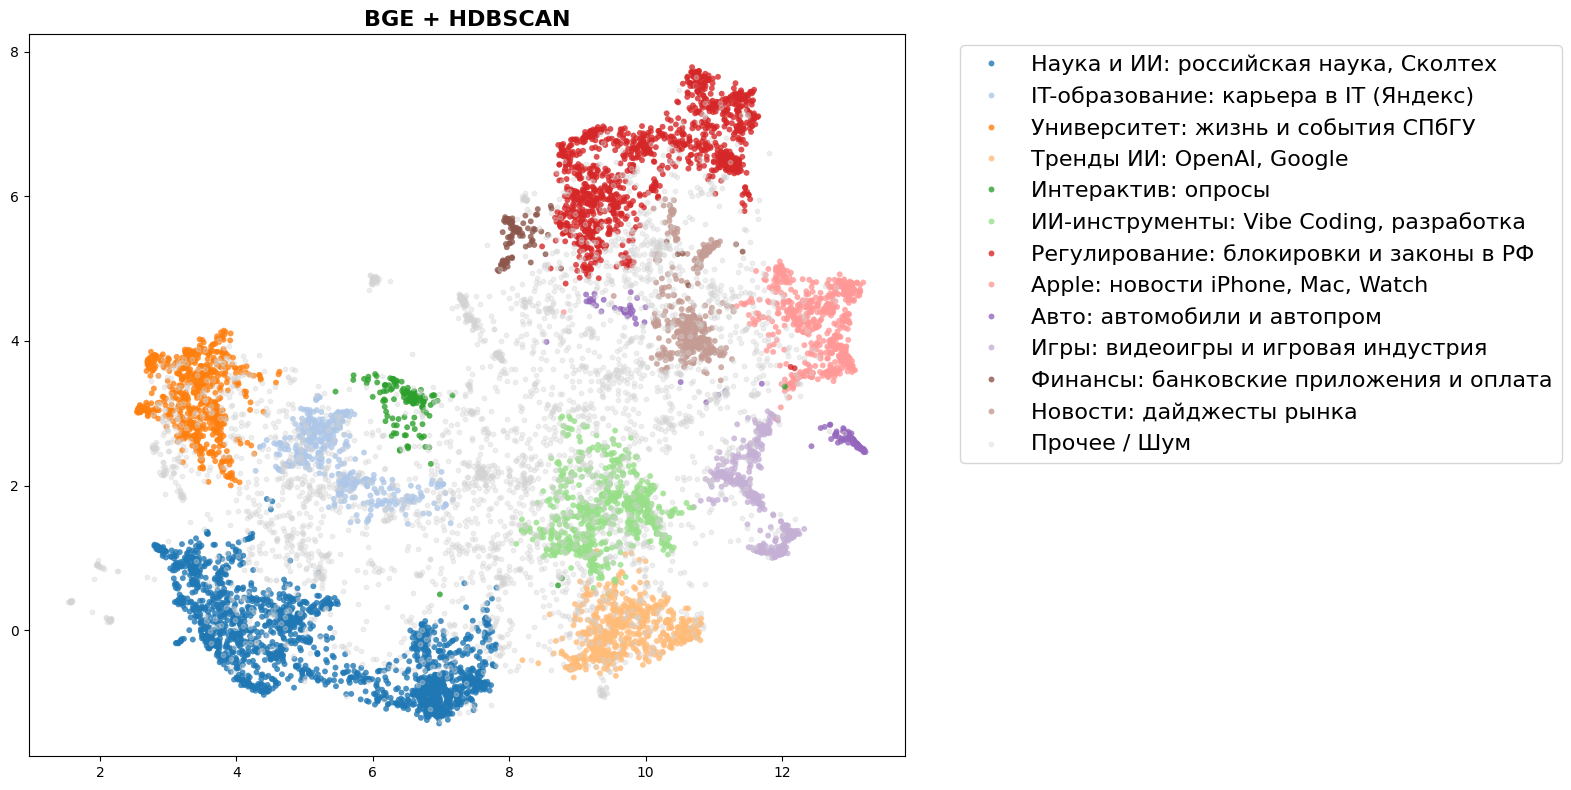

In [30]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

X_umap = umap_reducer.fit_transform(
    X_bge_norm
)

plt.figure(figsize=(16, 8))

mask_clusters = labels_hdbscan != -1

hue_names = pd.Series(labels_hdbscan).map(cluster_names_bge_hdbscan)

sns.scatterplot(
    x=X_umap[mask_clusters, 0],
    y=X_umap[mask_clusters, 1],
    hue=hue_names[mask_clusters],
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

mask_noise = labels_hdbscan == -1
plt.scatter(
    X_umap[mask_noise, 0],
    X_umap[mask_noise, 1],
    c='lightgray',
    s=10,
    alpha=0.35,
    label='Прочее / Шум'
)

plt.title(
    'BGE + HDBSCAN',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=16
)

plt.tight_layout()

os.makedirs(
    "../data/plots/bge/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/bge/hdbscan/"
    "bge_hdbscan_umap.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

HDBSCAN выделил 12 тематических кластеров. Однако около 31% постов были маркированы как шум.

Для практического анализа терять треть данных нецелесообразно. Поэтому применяем постобработку: вычисляем центроиды кластеров и присваиваем каждому шумовому посту ближайший кластер по косинусному расстоянию.

Центроиды имеющихся кластеров

In [185]:
valid_mask = labels_hdbscan != -1

X_core = X_hdbscan_final[valid_mask]
labels_core = labels_hdbscan[valid_mask]

centroids = {}

for c in np.unique(labels_core):

    centroids[c] = X_core[labels_core == c].mean(axis=0)

Присваиваем шум к ближайшим центроидам

In [186]:
from sklearn.metrics.pairwise import cosine_distances

X_noise = X_hdbscan_final[labels_hdbscan == -1]

noise_indices = np.where(labels_hdbscan == -1)[0]

assigned_clusters = []

for i in range(len(X_noise)):

    dists = []

    for c in centroids:

        dist = cosine_distances(
            X_noise[i].reshape(1, -1),
            centroids[c].reshape(1, -1)
        )[0][0]

        dists.append((c, dist))

    best_cluster = min(dists, key=lambda x: x[1])[0]
    assigned_clusters.append(best_cluster)

assigned_clusters = np.array(assigned_clusters)


Добавляем колонку в датафрейм

In [ ]:
labels_hdbscan_final = labels_hdbscan.copy()

labels_hdbscan_final[labels_hdbscan_final == -1] = assigned_clusters


df_hdbscan_cluster_final['cluster_bge_hdbscan_final'] = labels_hdbscan_final

In [195]:
cluster_sizes_final = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan_final']
    .value_counts()
    .sort_index()
)

df_hdbscan_cluster_final['cluster_bge_hdbscan_final_size'] = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan_final']
    .map(cluster_sizes_final)
)

df_hdbscan_cluster_final['cluster_bge_hdbscan_final_name'] = (
    df_hdbscan_cluster_final['cluster_bge_hdbscan_final']
    .map(cluster_names_bge_hdbscan)
)

df_hdbscan_cluster_final.head()

,post_id,channel_username,text,cluster_bge_hdbscan,cluster_bge_hdbscan_size,cluster_bge_hdbscan_name,cluster_bge_hdbscan_final,cluster_bge_hdbscan_final_size,cluster_bge_hdbscan_final_name
0,1813,AI_point_of_view,🤔 Искусственный интеллект: угроза или новые во...,3,1749,Российская наука и ИИ (Сколтех),3,2126,Российская наука и ИИ (Сколтех)
1,1809,AI_point_of_view,👩‍🎓 **Самообучение без разметки: лекция Алексе...,3,1749,Российская наука и ИИ (Сколтех),3,2126,Российская наука и ИИ (Сколтех)
2,1808,AI_point_of_view,📡▶️ **Искусственный интеллект: как научить маш...,3,1749,Российская наука и ИИ (Сколтех),3,2126,Российская наука и ИИ (Сколтех)
3,1805,AI_point_of_view,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,3,1749,Российская наука и ИИ (Сколтех),3,2126,Российская наука и ИИ (Сколтех)
4,1804,AI_point_of_view,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,-1,3314,Прочее / Шум,3,2126,Российская наука и ИИ (Сколтех)


Сохраняем

In [196]:
output_final = (
    "../data/results/final_clusters/bge_hdbscan/"
    "bge_hdbscan_final_clusters_no_noise.csv"
)

df_hdbscan_cluster_final.to_csv(output_final, index=False)

Посмотрим на итоговое распределение

In [198]:
df_hdbscan_cluster_final[
    'cluster_bge_hdbscan_final_name'
].value_counts()


cluster_bge_hdbscan_final_name
Российская наука и ИИ (Сколтех)             2126
Telegram: блокировки и законы в РФ          1377
ИИ для разработки (Vibe Coding)             1210
Жизнь и события СПбГУ                        942
Глобальная индустрия ИИ (OpenAI, Google)     911
Дайджесты новостей рынка                     761
Образование и карьера в IT (Яндекс)          751
Новости Apple (iPhone, Mac, Watch)           668
Видеоигры и игровая индустрия                537
Опросы                                       507
Банковские приложения и оплата (iOS)         477
Автомобили и автопром                        200
Name: count, dtype: int64

Визуализация

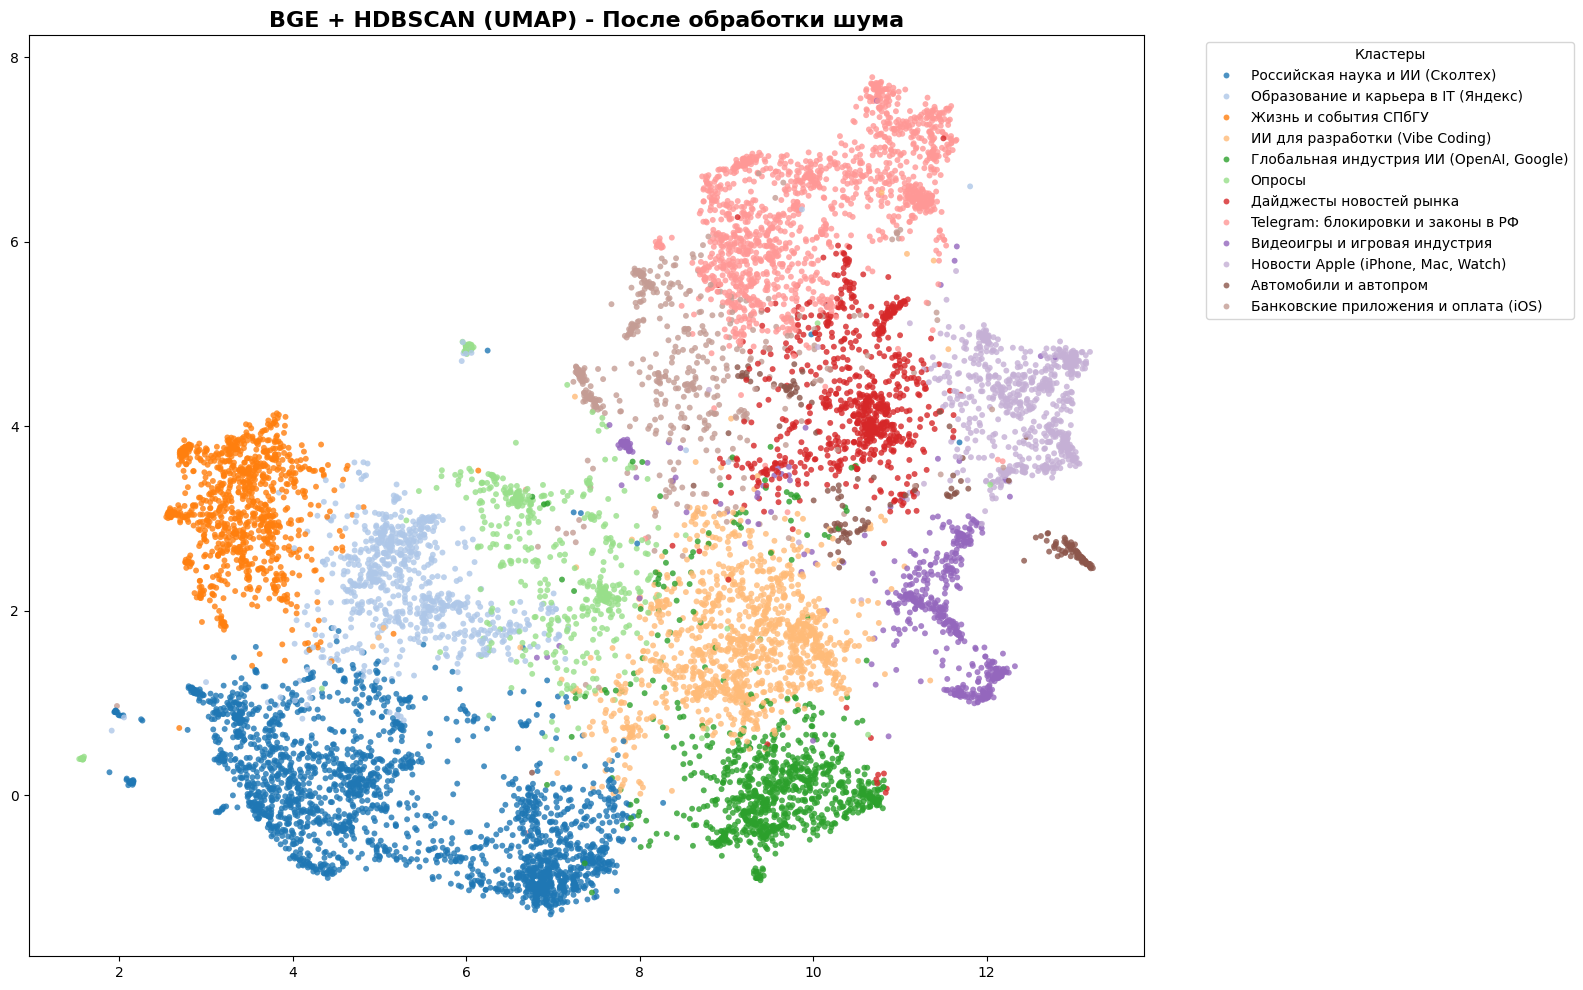

In [ ]:
X_umap_final = umap_reducer.fit_transform(X_bge_norm)

plt.figure(figsize=(16, 10))

labels_final = labels_hdbscan_final

hue_names_final = pd.Series(labels_final).map(cluster_names_bge_hdbscan)


sns.scatterplot(
    x=X_umap_final[:, 0],
    y=X_umap_final[:, 1],
    hue=hue_names_final,
    palette='tab20',
    s=18,
    alpha=0.8,
    linewidth=0
)

plt.title(
    'BGE + HDBSCAN (UMAP) - После обработки шума',
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Кластеры'
)

plt.tight_layout()

os.makedirs(
    "../data/plots/bge/hdbscan",
    exist_ok=True
)

plt.savefig(
    "../data/plots/bge/hdbscan/"
    "bge_hdbscan_umap_final_no_noise.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()